In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [6]:


def extract_daily_features(household_series):
    """
    Convert 15-min interval readings into daily statistical features
    FIXED: Handles missing values and length mismatches
    
    Parameters:
    household_series: pandas Series with datetime index and consumption values
    
    Returns:
    DataFrame with daily features
    """
    
    # First, ensure we have a proper datetime index
    if not isinstance(household_series.index, pd.DatetimeIndex):
        household_series.index = pd.to_datetime(household_series.index)
    
    # Remove any NaN values
    household_series = household_series.dropna()
    
    if len(household_series) == 0:
        return pd.DataFrame()  # Return empty DataFrame if no data
    
    # Resample to daily (sum for total daily consumption)
    # Use .fillna(0) to handle missing days
    daily = household_series.resample('D').sum()
    
    # Create features dataframe with the same index as daily
    features = pd.DataFrame(index=daily.index)
    
    # Total daily consumption
    features['total_daily'] = daily.values
    
    # Basic statistics of 15-min readings within each day
    # Use .agg() with proper handling
    daily_stats = household_series.resample('D').agg(['mean', 'std', 'min', 'max', 'median'])
    
    features['avg_consumption'] = daily_stats['mean'].values
    features['std_consumption'] = daily_stats['std'].fillna(0).values
    features['min_consumption'] = daily_stats['min'].values
    features['max_consumption'] = daily_stats['max'].values
    features['median_consumption'] = daily_stats['median'].values
    
    # Range (peak to trough)
    features['consumption_range'] = features['max_consumption'] - features['min_consumption']
    
    # Coefficient of variation (normalized variability)
    features['cv'] = features['std_consumption'] / (features['avg_consumption'] + 0.001)
    
    # ===== TIME-BASED FEATURES =====
    
    # Morning peak (6 AM - 9 AM) - average consumption
    # Create a copy with hour indicator
    household_hour = household_series.copy()
    household_hour.index = household_series.index
    
    # Define time masks
    morning_mask = (household_hour.index.hour >= 6) & (household_hour.index.hour < 9)
    evening_mask = (household_hour.index.hour >= 17) & (household_hour.index.hour < 20)
    night_mask = (household_hour.index.hour >= 23) | (household_hour.index.hour < 5)
    
    # Calculate daily aggregates
    morning_consumption = household_hour[morning_mask].resample('D').mean()
    evening_consumption = household_hour[evening_mask].resample('D').mean()
    night_consumption = household_hour[night_mask].resample('D').mean()
    
    # Align with features index (fill missing with 0)
    features['morning_peak'] = morning_consumption.reindex(features.index, fill_value=0).values
    features['evening_peak'] = evening_consumption.reindex(features.index, fill_value=0).values
    features['night_consumption'] = night_consumption.reindex(features.index, fill_value=0).values
    
    # Night ratio (night consumption / average)
    features['night_ratio'] = features['night_consumption'] / (features['avg_consumption'] + 0.001)
    
    # ===== ZERO DETECTION =====
    
    # Count how many 15-min intervals had zero or near-zero consumption
    zero_mask = household_series < 0.1
    zero_count = zero_mask.resample('D').sum()
    features['zero_intervals'] = zero_count.reindex(features.index, fill_value=0).values
    
    # Proportion of zeros
    features['zero_proportion'] = features['zero_intervals'] / 96
    
    # ===== PEAK ANALYSIS =====
    
    # Time of peak consumption (hour of day when max occurred)
    def get_peak_hour(day_data):
        if len(day_data) == 0 or day_data.max() == 0:
            return -1
        peak_idx = day_data.argmax()
        if peak_idx < len(day_data):
            return day_data.index[peak_idx].hour + day_data.index[peak_idx].minute/60
        return -1
    
    # Resample to daily and get peak hour for each day
    peak_hours = household_series.resample('D').apply(lambda x: get_peak_hour(x) if len(x) > 0 else -1)
    features['peak_hour'] = peak_hours.reindex(features.index, fill_value=-1).values
    
    # ===== RAMP UP/DOWN RATES =====
    
    # Morning ramp up (increase from 5 AM to 8 AM)
    morning_ramp_mask = (household_series.index.hour >= 5) & (household_series.index.hour < 8)
    morning_ramp = household_series[morning_ramp_mask].resample('D').apply(lambda x: x.max() - x.min() if len(x) > 0 else 0)
    features['morning_ramp'] = morning_ramp.reindex(features.index, fill_value=0).values
    
    # Evening ramp down (decrease from 8 PM to 11 PM)
    evening_ramp_mask = (household_series.index.hour >= 20) & (household_series.index.hour < 23)
    evening_ramp = household_series[evening_ramp_mask].resample('D').apply(lambda x: x.max() - x.min() if len(x) > 0 else 0)
    features['evening_ramp'] = evening_ramp.reindex(features.index, fill_value=0).values
    
    # ===== LOAD FACTOR =====
    # Load Factor = Average / Peak (measures consistency)
    features['load_factor'] = features['avg_consumption'] / (features['max_consumption'] + 0.001)
    
    # ===== WEEKDAY FEATURES =====
    features['day_of_week'] = features.index.dayofweek
    features['is_weekend'] = (features['day_of_week'] >= 5).astype(int)
    features['is_monday'] = (features['day_of_week'] == 0).astype(int)
    features['is_friday'] = (features['day_of_week'] == 4).astype(int)
    
    # ===== MONTH FEATURES =====
    features['month'] = features.index.month
    features['season'] = features['month'].apply(lambda x: 0 if x in [12,1,2] else 1 if x in [3,4,5] else 2 if x in [6,7,8] else 3)
    
    # ===== ROLLING STATISTICS (7-day window) =====
    features['rolling_7day_mean'] = features['total_daily'].rolling(7, min_periods=1).mean()
    features['rolling_7day_std'] = features['total_daily'].rolling(7, min_periods=1).std().fillna(0)
    features['rolling_7day_max'] = features['total_daily'].rolling(7, min_periods=1).max()
    
    # ===== ANOMALY SCORE (deviation from rolling stats) =====
    features['zscore_7day'] = (features['total_daily'] - features['rolling_7day_mean']) / (features['rolling_7day_std'] + 0.001)
    
    # Fill any remaining NaN values with 0
    features = features.fillna(0)
    
    # Replace infinite values with 0
    features = features.replace([np.inf, -np.inf], 0)
    
    return features

print(" Fixed feature extraction function loaded!")

 Fixed feature extraction function loaded!


In [7]:
households_to_process = df.columns[:50].tolist()
print(f"Processing {len(households_to_process)} households...")

all_features = []
all_labels = []

for i, household in enumerate(households_to_process):
    if i % 10 == 0:
        print(f"Processing household {i+1}/{len(households_to_process)}: {household}")
    
    # Extract features for this household
    household_features = extract_daily_features(df[household])
    household_features['household_id'] = household
    
    # Add row index as date
    household_features.reset_index(inplace=True)
    household_features.rename(columns={'index': 'date'}, inplace=True)
    
    all_features.append(household_features)

# Combine all features
features_df = pd.concat(all_features, ignore_index=True)
print(f"\n Features extracted!")
print(f"Total samples (household-days): {len(features_df):,}")
print(f"Number of features: {len(features_df.columns) - 2}")  # Excluding date and household_id
print(f"\nFeature columns:\n{features_df.columns.tolist()}")


Processing 50 households...
Processing household 1/50: MT_001
Processing household 11/50: MT_011
Processing household 21/50: MT_021
Processing household 31/50: MT_031
Processing household 41/50: MT_041

✅ Features extracted!
Total samples (household-days): 73,100
Number of features: 28

Feature columns:
['date', 'total_daily', 'avg_consumption', 'std_consumption', 'min_consumption', 'max_consumption', 'median_consumption', 'consumption_range', 'cv', 'morning_peak', 'evening_peak', 'night_consumption', 'night_ratio', 'zero_intervals', 'zero_proportion', 'peak_hour', 'morning_ramp', 'evening_ramp', 'load_factor', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday', 'month', 'season', 'rolling_7day_mean', 'rolling_7day_std', 'rolling_7day_max', 'zscore_7day', 'household_id']


In [8]:
print("\n" + "="*60)
print("CREATING SYNTHETIC ANOMALIES")
print("="*60)

def inject_anomaly(features_row, anomaly_type):
    """
    Modify a normal consumption pattern to simulate electricity theft
    
    Types:
    1. 'peak_clipping': Reduce peak consumption (meter tampering)
    2. 'zeroing': Zero out night consumption
    3. 'reduction': Overall reduction in consumption
    4. 'spike': Sudden spikes (illegal connection)
    5. 'shift': Shift consumption to different hours
    """
    
    row = features_row.copy()
    
    if anomaly_type == 'peak_clipping':
        # Cap peak consumption at 70% of original max
        row['max_consumption'] = row['max_consumption'] * 0.7
        row['consumption_range'] = row['max_consumption'] - row['min_consumption']
        row['load_factor'] = row['avg_consumption'] / (row['max_consumption'] + 0.001)
        row['evening_peak'] = row['evening_peak'] * 0.7
        
    elif anomaly_type == 'night_zeroing':
        # Zero out night consumption
        row['night_consumption'] = 0
        row['night_ratio'] = 0
        row['zero_intervals'] = row['zero_intervals'] + 24  # 6 hours * 4 readings
        row['zero_proportion'] = row['zero_intervals'] / 96
        
    elif anomaly_type == 'overall_reduction':
        # Reduce all consumption by 40%
        reduction = 0.4
        row['total_daily'] = row['total_daily'] * (1 - reduction)
        row['avg_consumption'] = row['avg_consumption'] * (1 - reduction)
        row['max_consumption'] = row['max_consumption'] * (1 - reduction)
        row['min_consumption'] = row['min_consumption'] * (1 - reduction)
        row['median_consumption'] = row['median_consumption'] * (1 - reduction)
        row['consumption_range'] = row['consumption_range'] * (1 - reduction)
        row['morning_peak'] = row['morning_peak'] * (1 - reduction)
        row['evening_peak'] = row['evening_peak'] * (1 - reduction)
        row['night_consumption'] = row['night_consumption'] * (1 - reduction)
        
    elif anomaly_type == 'spike':
        # Add sudden spikes (illegal high consumption)
        row['max_consumption'] = row['max_consumption'] * 2.5
        row['consumption_range'] = row['consumption_range'] * 2.5
        row['std_consumption'] = row['std_consumption'] * 2
        row['cv'] = row['cv'] * 2
        row['load_factor'] = row['load_factor'] * 0.4
        
    elif anomaly_type == 'consumption_shift':
        # Shift consumption from morning to night (meter tampering)
        row['morning_peak'] = row['morning_peak'] * 0.3
        row['night_consumption'] = row['night_consumption'] * 2
        row['night_ratio'] = row['night_ratio'] * 2
        row['morning_ramp'] = row['morning_ramp'] * 0.3
    
    return row

# Get normal samples (from first 10 households)
normal_samples = features_df[features_df['household_id'].isin(households_to_process[:10])].copy()
normal_samples = normal_samples.sample(5000)  # Take 5000 normal samples

# Create balanced dataset
anomaly_types = ['peak_clipping', 'night_zeroing', 'overall_reduction', 'spike', 'consumption_shift']
normal_samples_per_type = len(normal_samples) // len(anomaly_types)

labeled_data = []

# Add normal samples
for _, row in normal_samples.iterrows():
    row_copy = row.copy()
    row_copy['is_anomaly'] = 0
    row_copy['anomaly_type'] = 'normal'
    labeled_data.append(row_copy)

# Add anomaly samples
for anomaly_type in anomaly_types:
    print(f"Creating {anomaly_type} anomalies...")
    samples_for_type = normal_samples.sample(normal_samples_per_type)
    
    for _, row in samples_for_type.iterrows():
        anomaly_row = inject_anomaly(row, anomaly_type)
        anomaly_row['is_anomaly'] = 1
        anomaly_row['anomaly_type'] = anomaly_type
        labeled_data.append(anomaly_row)

# Create DataFrame
labeled_df = pd.DataFrame(labeled_data)
print(f"\n Labeled dataset created!")
print(f"Total samples: {len(labeled_df):,}")
print(f"Normal samples: {(labeled_df['is_anomaly'] == 0).sum():,}")
print(f"Anomaly samples: {(labeled_df['is_anomaly'] == 1).sum():,}")
print(f"Anomaly ratio: {labeled_df['is_anomaly'].mean():.2%}")

# Show anomaly type distribution
print("\nAnomaly type distribution:")
print(labeled_df['anomaly_type'].value_counts())



CREATING SYNTHETIC ANOMALIES
Creating peak_clipping anomalies...
Creating night_zeroing anomalies...
Creating overall_reduction anomalies...
Creating spike anomalies...
Creating consumption_shift anomalies...

 Labeled dataset created!
Total samples: 10,000
Normal samples: 5,000
Anomaly samples: 5,000
Anomaly ratio: 50.00%

Anomaly type distribution:
anomaly_type
normal               5000
peak_clipping        1000
night_zeroing        1000
overall_reduction    1000
spike                1000
consumption_shift    1000
Name: count, dtype: int64


In [9]:
feature_columns = ['total_daily', 'avg_consumption', 'std_consumption', 'min_consumption',
                   'max_consumption', 'median_consumption', 'consumption_range', 'cv',
                   'morning_peak', 'evening_peak', 'night_consumption', 'night_ratio',
                   'zero_intervals', 'zero_proportion', 'peak_hour', 'morning_ramp',
                   'evening_ramp', 'load_factor', 'day_of_week', 'is_weekend',
                   'is_monday', 'is_friday', 'month', 'season', 'rolling_7day_mean',
                   'rolling_7day_std', 'rolling_7day_max', 'zscore_7day']

# Check which features exist in our dataframe
available_features = [col for col in feature_columns if col in labeled_df.columns]
print(f"\nAvailable features: {len(available_features)}/{len(feature_columns)}")

# Separate features and labels
X = labeled_df[available_features].copy()
y = labeled_df['is_anomaly'].copy()
anomaly_types_df = labeled_df['anomaly_type'].copy()

# Handle infinite values and NaN
X = X.replace([np.inf, -np.inf], 0)
X = X.fillna(0)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=available_features)

print(f"\n Feature matrix shape: {X_scaled.shape}")
print(f"Label vector shape: {y.shape}")



Available features: 28/28

 Feature matrix shape: (10000, 28)
Label vector shape: (10000,)


In [10]:
X_scaled.to_csv('../data/processed/X_features.csv', index=False)
y.to_csv('../data/processed/y_labels.csv', index=False)
pd.DataFrame(anomaly_types_df).to_csv('../data/processed/anomaly_types.csv', index=False)

# Save full labeled dataset
labeled_df.to_csv('../data/processed/labeled_dataset.csv', index=False)

# Save scaler for later use
import joblib
joblib.dump(scaler, '../data/models/scaler.pkl')
joblib.dump(available_features, '../data/models/feature_columns.pkl')

print("\n All processed data saved!")
print("Files saved:")
print("  - X_features.csv (scaled features)")
print("  - y_labels.csv (anomaly labels)")
print("  - anomaly_types.csv (type of anomaly)")
print("  - labeled_dataset.csv (full dataset)")
print("  - scaler.pkl (standard scaler)")
print("  - feature_columns.pkl (feature names)")


 All processed data saved!
Files saved:
  - X_features.csv (scaled features)
  - y_labels.csv (anomaly labels)
  - anomaly_types.csv (type of anomaly)
  - labeled_dataset.csv (full dataset)
  - scaler.pkl (standard scaler)
  - feature_columns.pkl (feature names)


Checking alignment...
X_scaled shape: (10000, 28)
y shape: (10000,)
After reset: X shape: (10000, 28), y shape: (10000,)


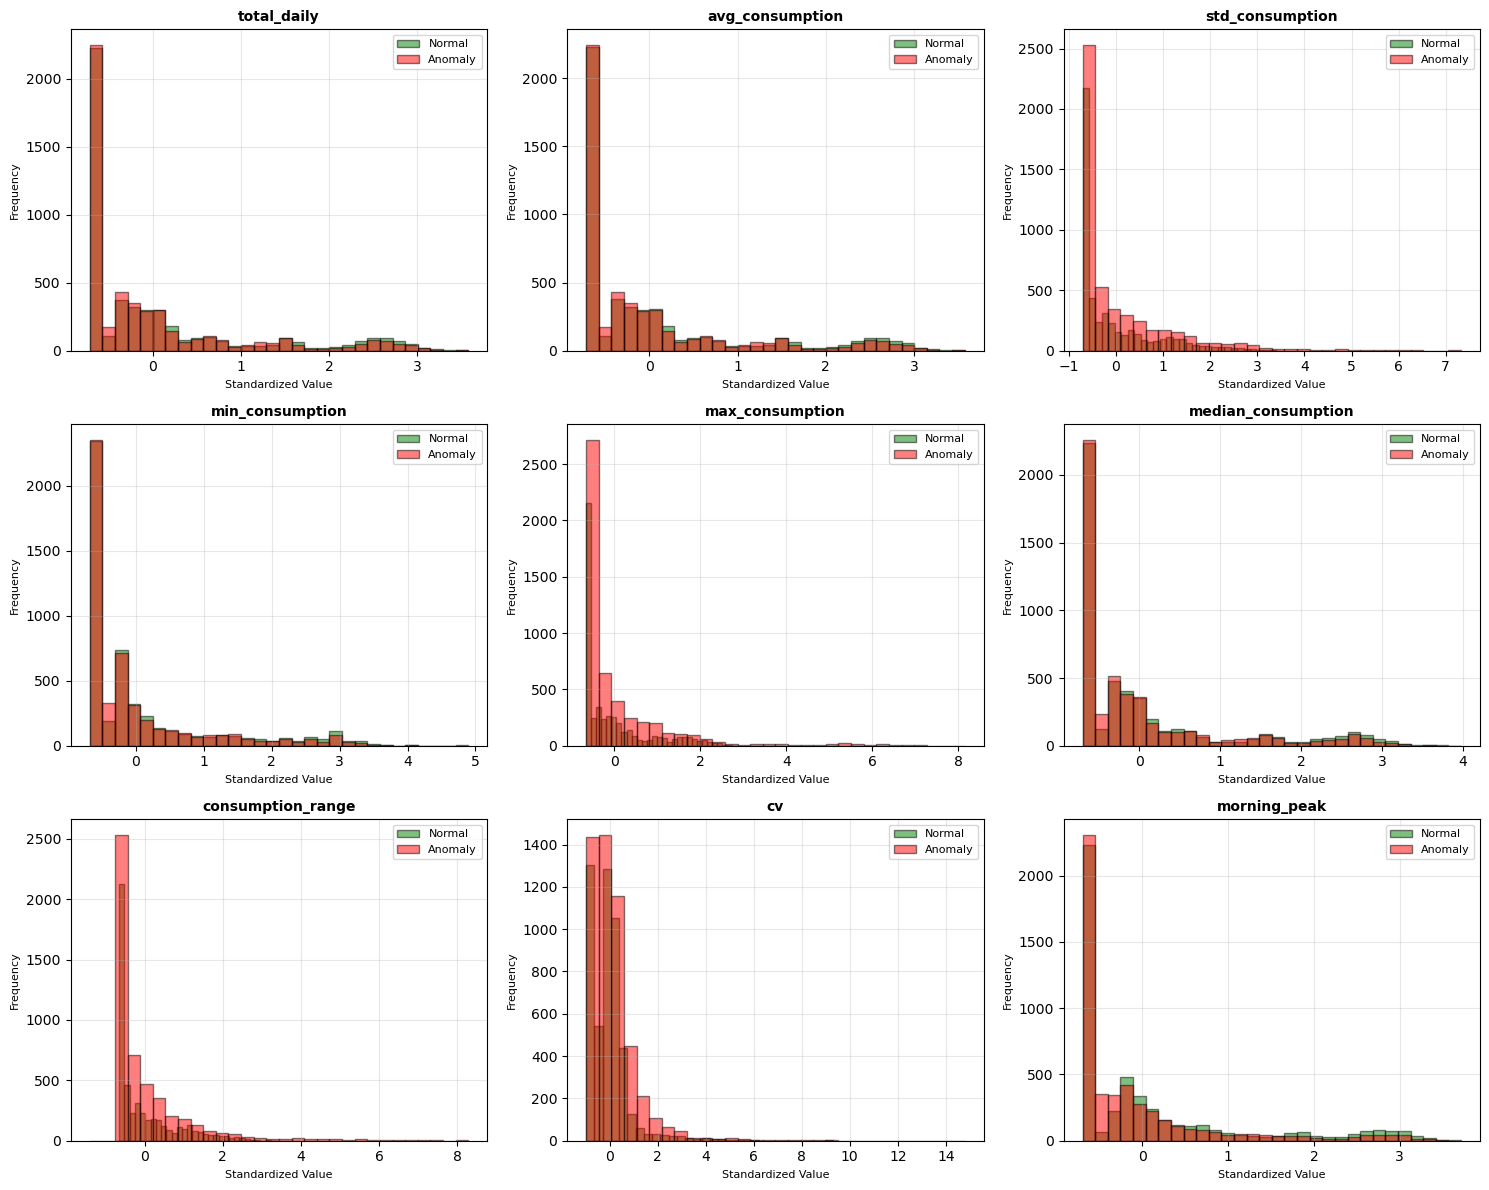


 Feature engineering complete! Ready for clustering and modeling.
 Feature distributions saved to: ../data/processed/feature_distributions.png


In [13]:
# ============================================
# CELL 7: Feature Importance Analysis (FIXED)
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure X_scaled and y are aligned
print("Checking alignment...")
print(f"X_scaled shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")

# Reset indices to ensure alignment
X_scaled_clean = X_scaled.reset_index(drop=True)
y_clean = pd.Series(y).reset_index(drop=True)

# Convert to numpy arrays for simpler indexing (avoids pandas index issues)
X_numpy = X_scaled_clean.values
y_numpy = y_clean.values

print(f"After reset: X shape: {X_numpy.shape}, y shape: {y_numpy.shape}")

# Get feature names
feature_names = available_features

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(feature_names[:9]):
    # Get the column index for this feature
    feature_idx = feature_names.index(feature)
    
    # Extract values using numpy indexing
    normal_values = X_numpy[y_numpy == 0, feature_idx]
    anomaly_values = X_numpy[y_numpy == 1, feature_idx]
    
    # Plot histograms
    axes[idx].hist(normal_values, bins=30, alpha=0.5, label='Normal', color='green', edgecolor='black')
    axes[idx].hist(anomaly_values, bins=30, alpha=0.5, label='Anomaly', color='red', edgecolor='black')
    axes[idx].set_title(f'{feature}', fontsize=10, fontweight='bold')
    axes[idx].legend(fontsize=8)
    axes[idx].set_xlabel('Standardized Value', fontsize=8)
    axes[idx].set_ylabel('Frequency', fontsize=8)
    axes[idx].grid(True, alpha=0.3)

# Hide any unused subplots
for idx in range(len(feature_names[:9]), 9):
    axes[idx].set_visible(False)

plt.tight_layout()

# Create directory if it doesn't exist
import os
os.makedirs('../data/processed', exist_ok=True)

plt.savefig('../data/processed/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Feature engineering complete! Ready for clustering and modeling.")
print(f" Feature distributions saved to: ../data/processed/feature_distributions.png")